# Auditing & Explainable AI (XAI) Model

**Objective:**
To audit *machine learning* algorithm decisions to ensure there is no undue bias and to provide operational transparency to the *Risk* team using SHAP value analysis.

**Audit Approach:**
1. **Global Interpretability (Summary Plot):** Audit which features, at a macro level, are most significant in triggering *fraud* alerts across the entire system.
2. **Local Interpretability (Waterfall/Force Plot):** Audits decisions regarding a specific transaction. If a customer’s transaction is blocked, the system must be able to explain the reason (e.g., “Blocked because the transaction location is 150 km from home and the merchant category is high-risk”).

In [10]:
import pandas as pd
import shap
import mlflow
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
# Inisialisasi visualisasi JS untuk SHAP
shap.initjs()

# 1. Memuat Data Preprocessed (Sample untuk Audit)
X_test = pd.read_parquet('../dataset/02_processed/test_processed.parquet').drop(columns=['is_fraud'])

# 2. Konfigurasi koneksi ke MLflow (Krusial untuk notebook baru)
mlflow.set_tracking_uri("http://localhost:5000")

# 3. Memuat Model Pemenang dari MLflow Registry
# Ganti string di bawah ini dengan RUN ID dari MLflow UI Anda
run_id = "d1b9e8809b224c4b8cb713848d2f9da9" 
logged_model = f'runs:/{run_id}/model_baseline_lgbm'

print(f"Downloading the model from the registry: {logged_model}")
best_model = mlflow.lightgbm.load_model(logged_model)
print(f"The LightGBM model was successfully loaded into memory!")

The LightGBM model was successfully loaded into memory!


## Phase 1: Global Model Audit (Feature Importance)
Evaluate the overall contribution of features to *fraud* detection. Ensure the model relies on business-logical metrics (such as distance and numerical values) rather than features that could introduce bias.

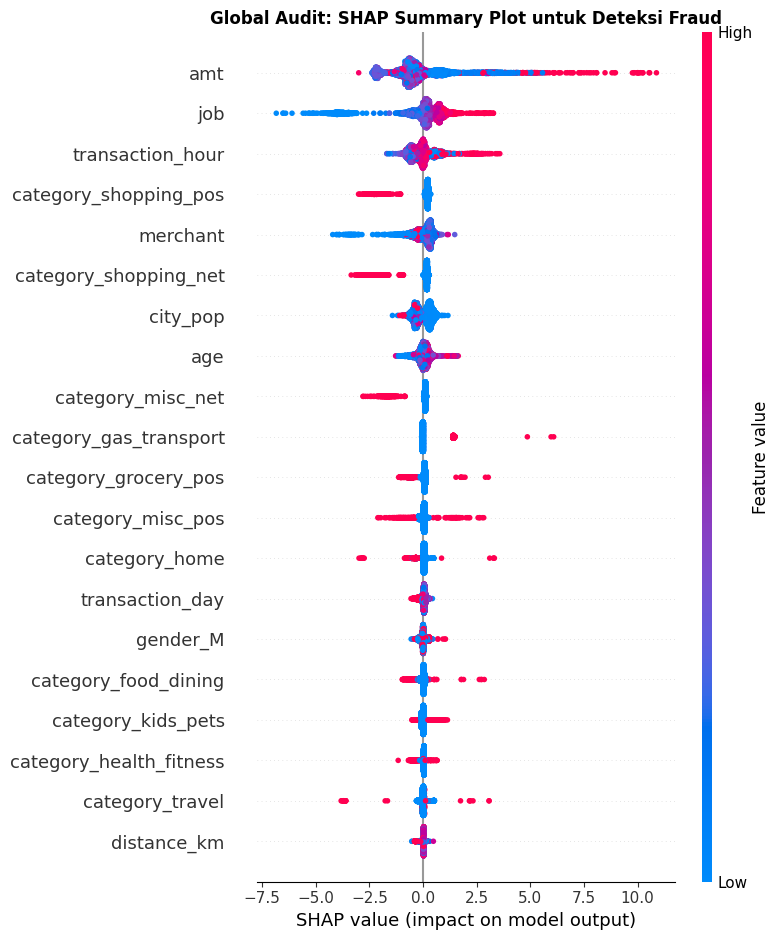

In [11]:
# Membuat Tree Explainer khusus untuk LightGBM
explainer = shap.TreeExplainer(best_model)
X_audit_sample = X_test.sample(5000, random_state=42)

shap_values = explainer.shap_values(X_audit_sample, check_additivity=False)

# Menampilkan Summary Plot
plt.title('Global Audit: SHAP Summary Plot untuk Deteksi Fraud', fontweight='bold')
shap.summary_plot(shap_values, X_audit_sample, plot_type="dot")

## Phase 2: Local Audit (Investigation of Individual Transactions)
A simulation of a *Risk Analyst* reviewing a specific transaction flagged by the model. We will analyze the *fraud* transaction with the highest probability to determine the reason for the rejection.

Mengaudit Transaksi ID: 42
Profil Fitur Transaksi:


,merchant,amt,city_pop,job,transaction_hour,transaction_day,age,distance_km,gender_M,category_food_dining,...,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel
785767,0.004561,-0.138794,-0.007812,0.004129,9,6,-0.48,0.398049,False,False,...,False,False,False,False,False,False,False,False,False,False


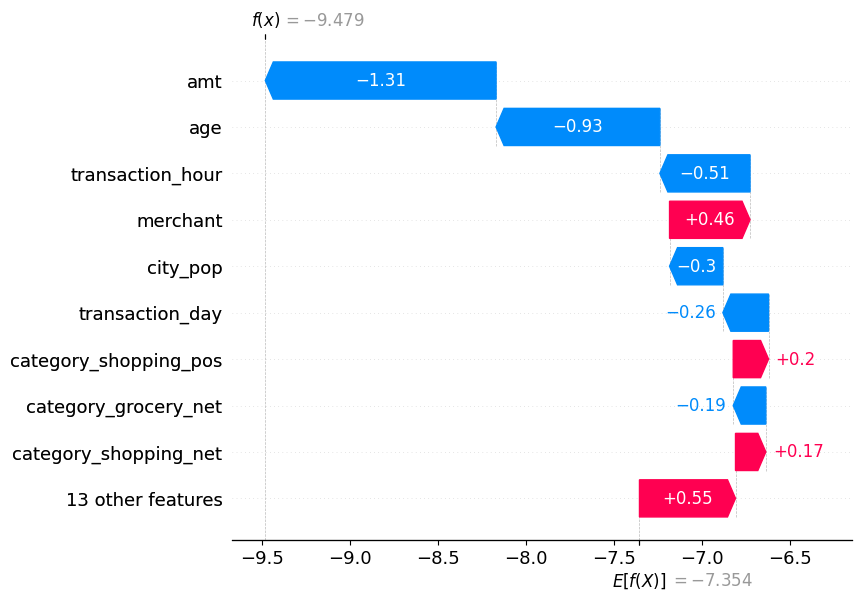

In [12]:
# Mencari indeks transaksi yang diprediksi sangat berisiko oleh model
# Asumsi y_pred_proba_b sudah dihitung sebelumnya, kita ambil sampel indeks ke-42 (contoh)
target_idx = 42

print(f"Mengaudit Transaksi ID: {target_idx}")
print("Profil Fitur Transaksi:")
display(X_test.iloc[target_idx:target_idx+1])

# Membuat Waterfall Plot untuk satu prediksi
# Menunjukkan bagaimana setiap fitur mendorong probabilitas dari *base value* hingga prediksi akhir
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value, 
    shap_values[target_idx], 
    feature_names=X_test.columns.tolist()
)

In [14]:
# Fase 3: Model Registration (Post-Audit)
# Mendaftarkan model yang telah diaudit sebagai versi Production

model_uri = f"runs:/{run_id}/model_baseline_lgbm"
registered_model = mlflow.register_model(model_uri=model_uri, name="Risk_LGBM_Production")

print(f"Nama Model: {registered_model.name}")
print(f"Versi: {registered_model.version}") 

Successfully registered model 'Risk_LGBM_Production'.
2026/10/06 07:45:19 WARNING mlflow.tracking._model_registry.fluent: Run with id d1b9e8809b224c4b8cb713848d2f9da9 has no artifacts at artifact path 'model_baseline_lgbm', registering model based on models:/m-6a85d97559a947debf155aecaafdeba3 instead
2026/10/06 07:45:19 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Risk_LGBM_Production, version 1


Nama Model: Risk_LGBM_Production
Versi: 1


Created version '1' of model 'Risk_LGBM_Production'.


## Phase 4: Cross-Platform Model Export
Extract the winning model from the MLflow Registry and save it in a platform-agnostic format for deployment on various platforms (Web, Mobile, and Native Engine).

In [15]:
import os
import joblib

# 1. Membuat direktori 'models' di root proyek jika belum ada
export_dir = '../models'
os.makedirs(export_dir, exist_ok=True)

# Memastikan best_model (LightGBM) sudah termuat dari MLflow di Phase sebelumnya
# best_model = mlflow.lightgbm.load_model(...)

# 2. Ekspor ke Format Pickle (.pkl)
# Digunakan untuk backend berbasis Python (FastAPI, Flask, Streamlit)
pkl_path = os.path.join(export_dir, 'risk_lgbm_v1.pkl')
joblib.dump(best_model, pkl_path)
print(f"[Python Ecosystem] Model diekspor ke: {pkl_path}")

# 3. Ekspor ke Format Native LightGBM (.txt)
# Digunakan untuk integrasi bahasa C++ atau aplikasi mobile (Flutter/Dart via FFI)
txt_path = os.path.join(export_dir, 'risk_lgbm_v1.txt')
best_model.booster_.save_model(txt_path)
print(f"[Native/Mobile Ecosystem] Model diekspor ke: {txt_path}")

[Python Ecosystem] Model diekspor ke: ../models/risk_lgbm_v1.pkl
[Native/Mobile Ecosystem] Model diekspor ke: ../models/risk_lgbm_v1.txt
